In [1]:
!pip install tensorflow numpy matplotlib --quiet

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Reshape, Flatten, Embedding, Concatenate
from tensorflow.keras.layers import BatchNormalization, LeakyReLU, Conv2DTranspose, Conv2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(X_train, y_train), (_, _) = fashion_mnist.load_data()

# Normalize images
X_train = X_train / 127.5 - 1.0
X_train = np.expand_dims(X_train, axis=-1)

print("Shape:", X_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (60000, 28, 28, 1)


In [4]:
labels_text = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [5]:
def build_generator():
    noise = tf.keras.Input(shape=(100,))
    label = tf.keras.Input(shape=(1,), dtype='int32')

    label_embedding = Embedding(10, 50)(label)
    label_embedding = Flatten()(label_embedding)

    model_input = Concatenate()([noise, label_embedding])

    x = Dense(256)(model_input)
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)

    x = Dense(512)(x)
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)

    x = Dense(28*28, activation='tanh')(x)
    output = Reshape((28, 28, 1))(x)

    return Model([noise, label], output)

generator = build_generator()
generator.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        500 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     38,656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 512)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 784)       │    402,192 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 576,004 (2.20 MB)

 Trainable params: 574,468 (2.19 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [6]:
def build_discriminator():
    image = tf.keras.Input(shape=(28, 28, 1))
    label = tf.keras.Input(shape=(1,), dtype='int32')

    label_embedding = Embedding(10, 50)(label)
    label_embedding = Flatten()(label_embedding)
    label_embedding = Dense(28*28)(label_embedding)
    label_embedding = Reshape((28, 28, 1))(label_embedding)

    merged = Concatenate()([image, label_embedding])

    x = Conv2D(64, kernel_size=3, strides=2, padding='same')(merged)
    x = LeakyReLU()(x)

    x = Flatten()(x)
    x = Dense(1, activation='sigmoid')(x)

    return Model([image, label], x)

discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
discriminator.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        500 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 784)       │     39,984 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │      1,216 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 12544)     │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │     12,545 │ flatten_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,245 (211.89 KB)

 Trainable params: 54,245 (211.89 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
discriminator.trainable = False

noise = tf.keras.Input(shape=(100,))
label = tf.keras.Input(shape=(1,))

generated_image = generator([noise, label])
validity = discriminator([generated_image, label])

gan = Model([noise, label], validity)
gan.compile(loss='binary_crossentropy', optimizer='adam')

In [11]:
def train_gan(epochs=1000, batch_size=32):
    half_batch = batch_size // 2

    for epoch in range(epochs):
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_images = X_train[idx]
        real_labels = y_train[idx]

        noise = np.random.normal(0, 1, (half_batch, 100))
        fake_images = generator.predict([noise, real_labels])

        d_loss_real = discriminator.train_on_batch([real_images, real_labels], np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch([fake_images, real_labels], np.zeros((half_batch, 1)))

        noise = np.random.normal(0, 1, (batch_size, 100))
        sampled_labels = np.random.randint(0, 10, batch_size)

        g_loss = gan.train_on_batch([noise, sampled_labels], np.ones((batch_size, 1)))

        if epoch % 200 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss_real[0]} | G Loss: {g_loss}")
            generate_images(epoch)

In [12]:
def generate_images(epoch):
    noise = np.random.normal(0, 1, (10, 100))
    labels = np.arange(0, 10)

    gen_images = generator.predict([noise, labels])

    gen_images = 0.5 * gen_images + 0.5

    plt.figure(figsize=(10,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(gen_images[i, :, :, 0], cmap='gray')
        plt.title(labels_text[i])
        plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Epoch 0 | D Loss: 1.8703712224960327 | G Loss: 0.07755322754383087
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


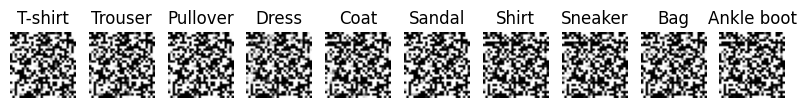

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

In [14]:
train_gan(epochs=100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


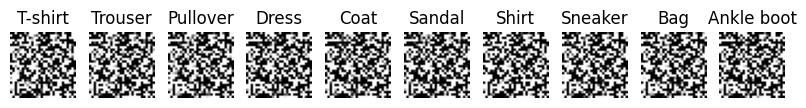

In [15]:
generate_images("Final Output")